In [1]:
import pandas as pd
import statsmodels.api as sm
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("prepared_data.csv")

In [3]:
df.columns

Index(['Unnamed: 0', 'Age', 'Gender_Female', 'Gender_Male',
       'Education_Bachelor', 'Education_HSC', 'Education_Master',
       'Education_PhD', 'Education_SSC', 'Industry_Education',
       'Industry_Finance', 'Industry_Healthcare', 'Industry_Marketing-Media',
       'Industry_Others', 'Industry_Student', 'Industry_Technology-IT',
       'AI_Knowledge_Beginner', 'AI_Knowledge_Expert',
       'AI_Knowledge_Intermediate', 'AI_Usage_Daily',
       'AI_Usage_Monthly- A few times', 'AI_Usage_Never',
       'AI_Usage_Weekly- A few times', 'AI_Helpfulness_Maybe',
       'AI_Helpfulness_No', 'AI_Helpfulness_Yes', 'AI_Concern_Maybe',
       'AI_Concern_No', 'AI_Concern_Yes', 'Alexa', 'ChatGPT', 'Deep Seek',
       'Gemini', 'Google Assistant', 'Grammarly', 'None-above', 'Notion-AI',
       'Siri', 'Unnamed: 38', 'Assignment', 'Automation', 'Coding',
       'Data-Analysis', 'Education', 'Medical', 'Personal-Use',
       'Project works', 'Translation, Presentation, Severel Writings',
      

# H1

In [ ]:
# try with ch_2
import pandas as pd
from scipy.stats import chi2_contingency

# Create contingency table
table = pd.crosstab(df["Industry_Education"], df["AI_Helpfulness_Yes"])

print("Contingency Table:")
print(table)

# Chi-square test
chi2, p, dof, expected = chi2_contingency(table)

print("\nChi-square statistic:", chi2)
print("p-value:", p)


Contingency Table:
AI_Helpfulness_Yes   0    1
Industry_Education         
0                   81  111
1                   15   13

Chi-square statistic: 0.866319194428443
p-value: 0.3519763307419469


In [19]:
import pandas as pd
import statsmodels.api as sm

# Assuming your dataframe is named 'df'
# We will create two models to test both parts of H1

# --- Part 1: Trust in AI recommendations ---
# DV: AI_Helpful_High (or whichever column represents High Trust)
# IVs: Industry_Education + Controls (Age, Gender_Male, etc.)

X = df[["Age",

    "Gender_Male",
    "Gender_Female",

    # Industry (reference = other industries)
    "Industry_Education",
    "Industry_Student"
    ]] # Add more control variables here
X = sm.add_constant(X) # Adds the intercept term
y_trust = df['AI_Helpfulness_Yes']

model_trust = sm.Logit(y_trust, X).fit()

print("--- RESULTS FOR TRUST (Part 1 of H1) ---")
print(model_trust.summary())

# --- Part 2: Concern about AI systems ---
# DV: AI_Concern_High
y_concern = df['AI_Concern_Yes']

model_concern = sm.Logit(y_concern, X).fit()

print("\n--- RESULTS FOR CONCERN (Part 2 of H1) ---")
print(model_concern.summary())

Optimization terminated successfully.
         Current function value: 0.679425
         Iterations 6
--- RESULTS FOR TRUST (Part 1 of H1) ---
                           Logit Regression Results                           
Dep. Variable:     AI_Helpfulness_Yes   No. Observations:                  220
Model:                          Logit   Df Residuals:                      215
Method:                           MLE   Df Model:                            4
Date:                Fri, 13 Feb 2026   Pseudo R-squ.:                0.008177
Time:                        00:30:03   Log-Likelihood:                -149.47
converged:                       True   LL-Null:                       -150.71
Covariance Type:            nonrobust   LLR p-value:                    0.6510
                         coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------
const                  0.5536        nan        nan

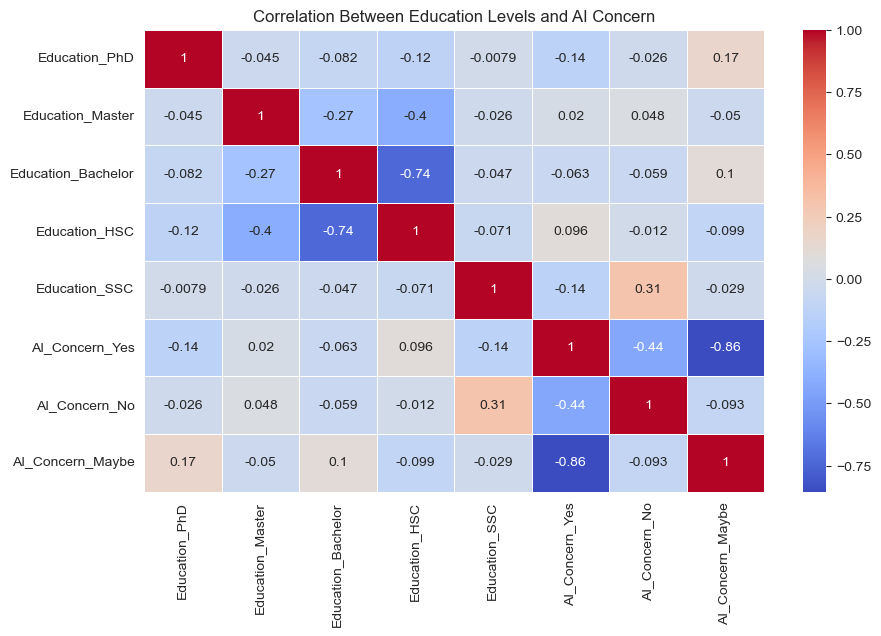

In [24]:
# Select all education-related columns + concern columns
education_cols = ["Education_PhD", "Education_Master", "Education_Bachelor", "Education_HSC", "Education_SSC"
]

concern_cols = ["AI_Concern_Yes", "AI_Concern_No", "AI_Concern_Maybe"
]

# Combine the columns
corr_data = df[education_cols + concern_cols]

# Compute correlations
corr_matrix = corr_data.corr()

# Plot heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", linewidths=0.5)
plt.title("Correlation Between Education Levels and AI Concern")
plt.show()

Optimization terminated successfully.
         Current function value: 0.443837
         Iterations 6


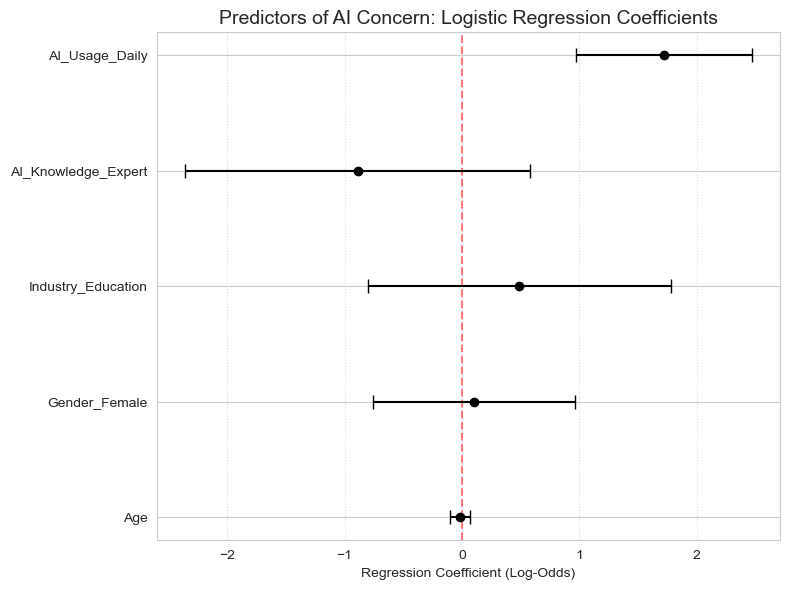

In [27]:
import statsmodels.api as sm
import matplotlib.pyplot as plt
import pandas as pd

# 1. Prepare data (fix the 'Gender' issue by only using one gender column)
X = df[['Age', 'Gender_Female', 'Industry_Education', 'AI_Knowledge_Expert', 'AI_Usage_Daily']]
X = sm.add_constant(X)
y = df['AI_Concern_Yes'] # Or AI_Helpful_High

# 2. Fit the model
model = sm.Logit(y, X).fit()

# 3. Extract coefficients and confidence intervals
results_df = pd.DataFrame({
    'params': model.params,
    'conf_lower': model.conf_int()[0],
    'conf_upper': model.conf_int()[1]
}).drop('const') # Drop the intercept for the plot

# 4. Create the Plot
plt.figure(figsize=(8, 6))
plt.axvline(x=0, color='red', linestyle='--', alpha=0.5) # The "No Effect" line

for i, row in enumerate(results_df.index):
    plt.errorbar(results_df.loc[row, 'params'], i, 
                 xerr=[[results_df.loc[row, 'params'] - results_df.loc[row, 'conf_lower']], 
                       [results_df.loc[row, 'conf_upper'] - results_df.loc[row, 'params']]],
                 fmt='o', color='black', capsize=5)

plt.yticks(range(len(results_df)), results_df.index)
plt.xlabel('Regression Coefficient (Log-Odds)')
plt.title('Predictors of AI Concern: Logistic Regression Coefficients', fontsize=14)
plt.grid(axis='x', linestyle=':', alpha=0.7)

plt.tight_layout()
plt.savefig('logit_coefficient_plot.png')

# H2

In [30]:
import pandas as pd
import statsmodels.api as sm
import numpy as np

# 1. Define variables for H2
# We include Age and Gender as controls to ensure the effect is truly from knowledge
X = df[['AI_Knowledge_Beginner', 'AI_Knowledge_Expert',
       'AI_Knowledge_Intermediate', 'Age', 'Gender_Female']] 
X = sm.add_constant(X)
y = df['AI_Helpfulness_Yes']

# 2. Fit the model
model_h2 = sm.Logit(y, X).fit()

# 3. Calculate Odds Ratios (OR) for easier interpretation
# OR > 1 means the factor increases the likelihood of finding AI helpful
params = model_h2.params
conf = model_h2.conf_int()
conf['OR'] = params
conf.columns = ['Lower CI', 'Upper CI', 'OR']
odds_ratios = np.exp(conf)

print("--- LOGISTIC REGRESSION RESULTS FOR H2 ---")
print(model_h2.summary())
print("\n--- ODDS RATIOS ---")
print(odds_ratios)

Optimization terminated successfully.
         Current function value: 0.681250
         Iterations 5
--- LOGISTIC REGRESSION RESULTS FOR H2 ---
                           Logit Regression Results                           
Dep. Variable:     AI_Helpfulness_Yes   No. Observations:                  220
Model:                          Logit   Df Residuals:                      214
Method:                           MLE   Df Model:                            5
Date:                Fri, 13 Feb 2026   Pseudo R-squ.:                0.005512
Time:                        00:58:14   Log-Likelihood:                -149.88
converged:                       True   LL-Null:                       -150.71
Covariance Type:            nonrobust   LLR p-value:                    0.8937
                                coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------------
const                         0.290

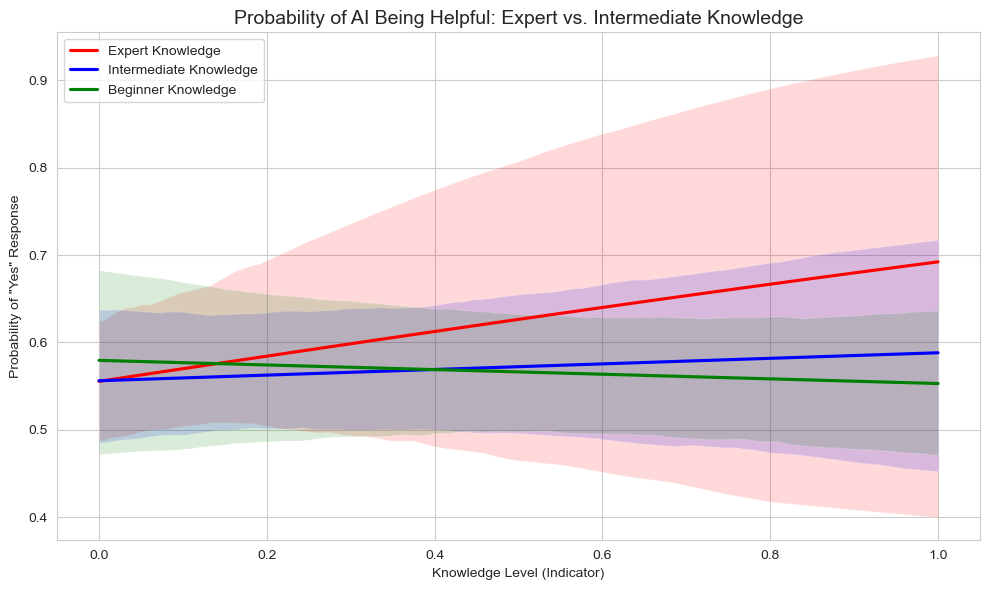

In [38]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

# Plot for Experts
sns.regplot(x='AI_Knowledge_Expert', y='AI_Helpfulness_Yes', data=df, 
            logistic=True, ci=95, label='Expert Knowledge', color='red', scatter=False)

# Plot for Intermediates
sns.regplot(x='AI_Knowledge_Intermediate', y='AI_Helpfulness_Yes', data=df, 
            logistic=True, ci=95, label='Intermediate Knowledge', color='blue', scatter=False)
# Plot for Beginner
sns.regplot(x='AI_Knowledge_Beginner', y='AI_Helpfulness_Yes', data=df, 
            logistic=True, ci=95, label='Beginner Knowledge', color='green', scatter=False)

plt.title('Probability of AI Being Helpful: Expert vs. Intermediate Knowledge', fontsize=14)
plt.xlabel('Knowledge Level (Indicator)')
plt.ylabel('Probability of "Yes" Response')
plt.legend()
plt.tight_layout()
plt.show()

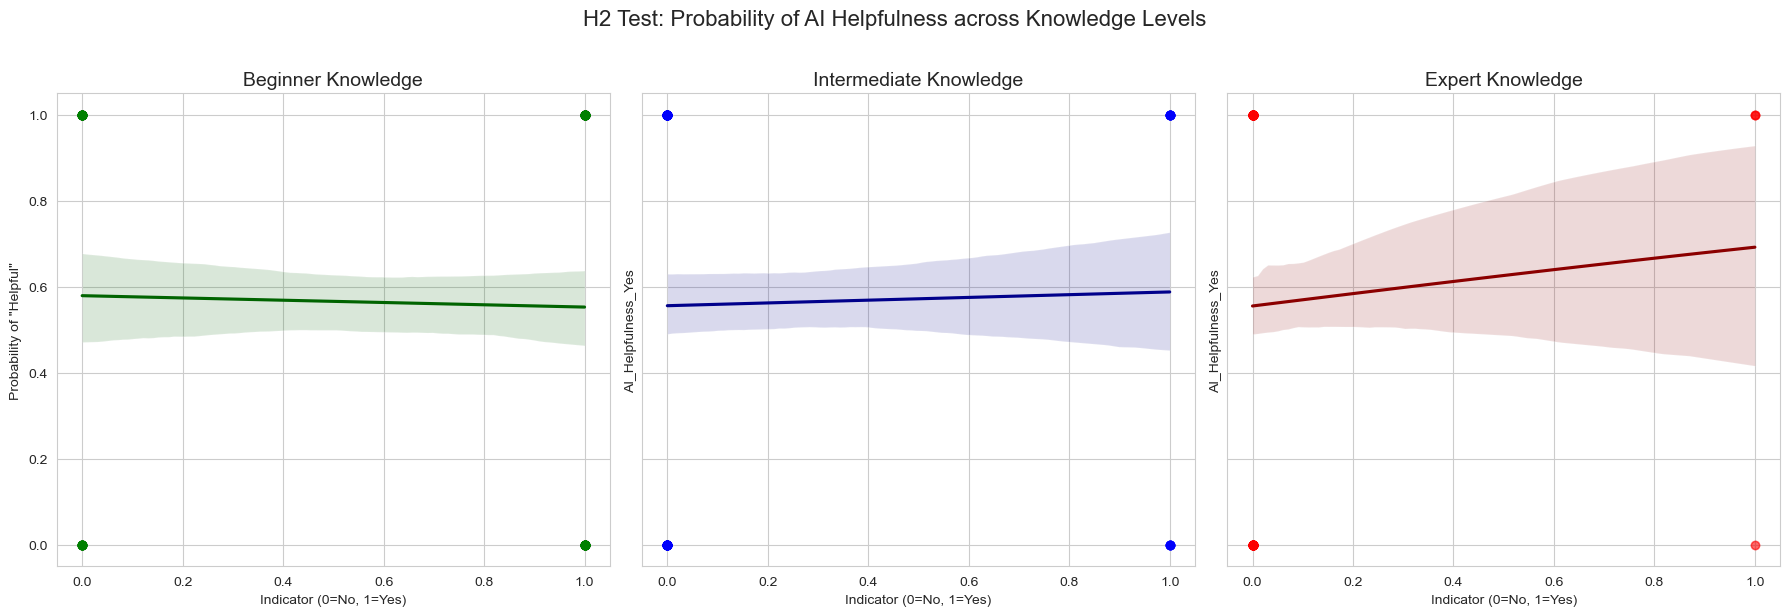

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set the style for a professional look
sns.set_style("whitegrid")

# Create a figure with 1 row and 3 columns
# sharey=True ensures all graphs use the same vertical scale for fair comparison
fig, axes = plt.subplots(1, 3, figsize=(18, 6), sharey=True)

# 1. Plot for Beginner
sns.regplot(x='AI_Knowledge_Beginner', y='AI_Helpfulness_Yes', data=df, 
            logistic=True, ci=95, ax=axes[0], color='green', 
            scatter_kws={'alpha':0.2}, line_kws={'color':'darkgreen', 'label':'Beginner'})
axes[0].set_title('Beginner Knowledge', fontsize=14)
axes[0].set_xlabel('Indicator (0=No, 1=Yes)')
axes[0].set_ylabel('Probability of "Helpful"')

# 2. Plot for Intermediate
sns.regplot(x='AI_Knowledge_Intermediate', y='AI_Helpfulness_Yes', data=df, 
            logistic=True, ci=95, ax=axes[1], color='blue', 
            scatter_kws={'alpha':0.2}, line_kws={'color':'darkblue', 'label':'Intermediate'})
axes[1].set_title('Intermediate Knowledge', fontsize=14)
axes[1].set_xlabel('Indicator (0=No, 1=Yes)')

# 3. Plot for Expert
sns.regplot(x='AI_Knowledge_Expert', y='AI_Helpfulness_Yes', data=df, 
            logistic=True, ci=95, ax=axes[2], color='red', 
            scatter_kws={'alpha':0.2}, line_kws={'color':'darkred', 'label':'Expert'})
axes[2].set_title('Expert Knowledge', fontsize=14)
axes[2].set_xlabel('Indicator (0=No, 1=Yes)')

# Add a main title for the whole layout
plt.suptitle('H2 Test: Probability of AI Helpfulness across Knowledge Levels', fontsize=16, y=1.02)

plt.tight_layout()
#plt.savefig('h2_comparison_subplots.png')
plt.show()

# H3

C:\Users\ashik\AppData\Local\Temp\ipykernel_15220\4235447809.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="Usage", y="Proportion_Not_Concerned", data=plot_df, palette="viridis")


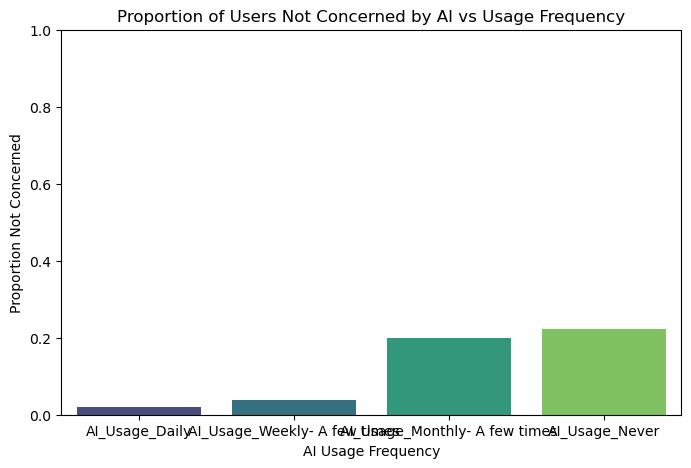

In [16]:
# AI usage columns
usage_cols = [
    "AI_Usage_Daily",
    "AI_Usage_Weekly- A few times",
    "AI_Usage_Monthly- A few times",
    "AI_Usage_Never"
]

# Compute proportion of "Not Concerned" for each usage
proportions = {}
for col in usage_cols:
    subset = df[df[col] == 1]  # users with this usage
    prop = subset["AI_Concern_No"].mean()  # proportion not concerned
    proportions[col] = prop

# Convert to dataframe for plotting
plot_df = pd.DataFrame({
    "Usage": list(proportions.keys()),
    "Proportion_Not_Concerned": list(proportions.values())
})

# --- Bar plot ---
plt.figure(figsize=(8,5))
sns.barplot(x="Usage", y="Proportion_Not_Concerned", data=plot_df, palette="viridis")
plt.ylim(0,1)
plt.title("Proportion of Users Not Concerned by AI vs Usage Frequency")
plt.ylabel("Proportion Not Concerned")
plt.xlabel("AI Usage Frequency")
plt.show()

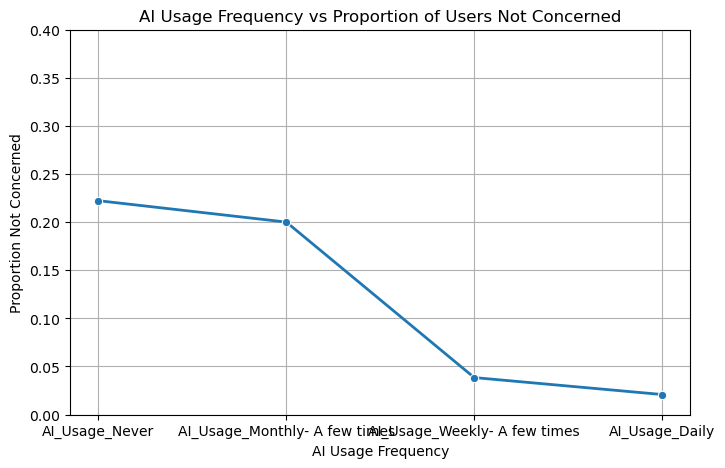

In [17]:
# AI usage columns
usage_cols = [
    "AI_Usage_Never",
    "AI_Usage_Monthly- A few times",
    "AI_Usage_Weekly- A few times",
    "AI_Usage_Daily"
]

# Compute proportion of "Not Concerned" for each usage
proportions = []
for col in usage_cols:
    subset = df[df[col] == 1]
    prop = subset["AI_Concern_No"].mean()
    proportions.append(prop)

# Plot line curve
plt.figure(figsize=(8,5))
sns.lineplot(x=usage_cols, y=proportions, marker='o', linewidth=2)
plt.ylim(0,0.4)
plt.title("AI Usage Frequency vs Proportion of Users Not Concerned")
plt.ylabel("Proportion Not Concerned")
plt.xlabel("AI Usage Frequency")
plt.grid(True)
plt.show()

C:\Users\ashik\AppData\Local\Temp\ipykernel_15220\4291733898.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="AI_Model", y="User_Count", data=plot_df, palette="viridis")


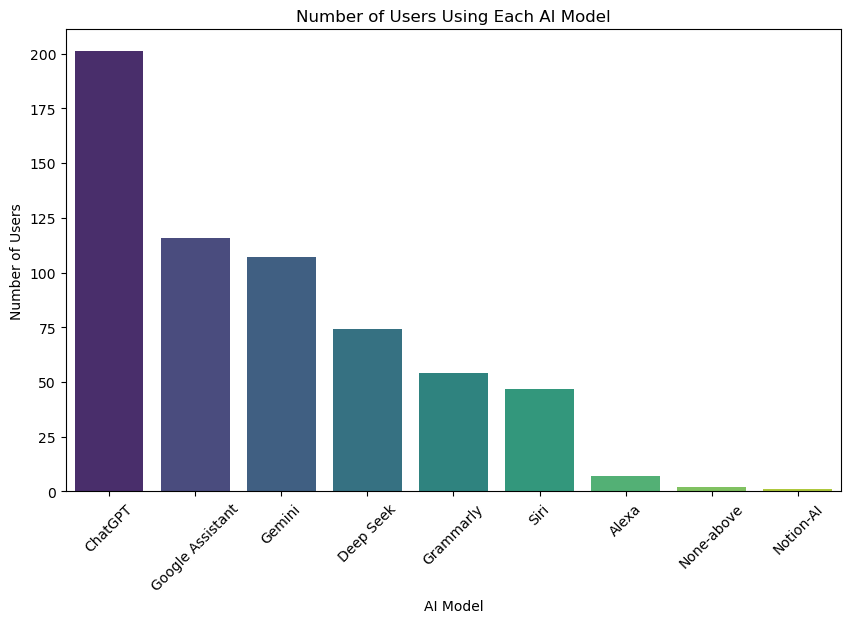

In [18]:
# List of AI model columns (binary 0/1)
ai_models = [
    "Alexa", "ChatGPT", "Deep Seek", "Gemini", "Google Assistant",
    "Grammarly", "None-above", "Notion-AI", "Siri"
]

# Count of users using each model
model_counts = df[ai_models].sum().sort_values(ascending=False)

# Convert to dataframe for plotting
plot_df = model_counts.reset_index()
plot_df.columns = ["AI_Model", "User_Count"]

# Bar plot
plt.figure(figsize=(10,6))
sns.barplot(x="AI_Model", y="User_Count", data=plot_df, palette="viridis")
plt.title("Number of Users Using Each AI Model")
plt.ylabel("Number of Users")
plt.xlabel("AI Model")
plt.xticks(rotation=45)
plt.show()

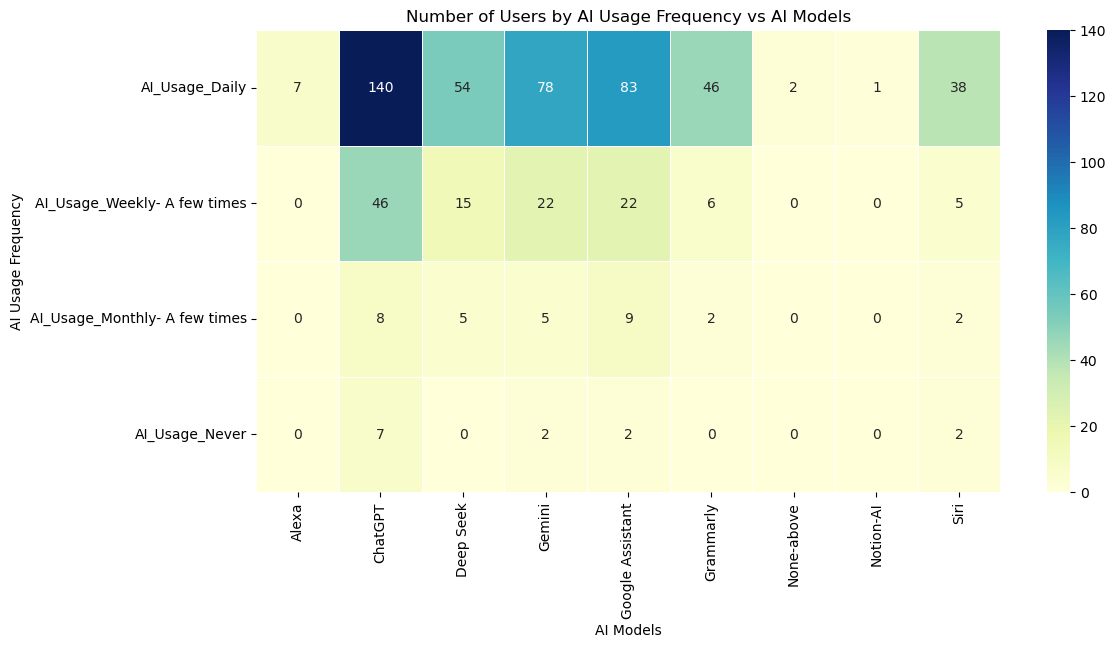

In [19]:
# AI usage columns
usage_cols = [
    "AI_Usage_Daily",
    "AI_Usage_Weekly- A few times",
    "AI_Usage_Monthly- A few times",
    "AI_Usage_Never"
]

# AI model columns
ai_models = [
    "Alexa", "ChatGPT", "Deep Seek", "Gemini", "Google Assistant",
    "Grammarly", "None-above", "Notion-AI", "Siri"
]

# Create a matrix of counts: usage frequency vs AI model
heatmap_data = pd.DataFrame(index=usage_cols, columns=ai_models)

for usage in usage_cols:
    subset = df[df[usage] == 1]
    counts = subset[ai_models].sum()
    heatmap_data.loc[usage] = counts

# Convert to numeric
heatmap_data = heatmap_data.astype(int)

# Plot heatmap
plt.figure(figsize=(12,6))
sns.heatmap(heatmap_data, annot=True, fmt="d", cmap="YlGnBu", linewidths=0.5)
plt.title("Number of Users by AI Usage Frequency vs AI Models")
plt.ylabel("AI Usage Frequency")
plt.xlabel("AI Models")
plt.show()

In [20]:
# Predictor
X = df[['Age', 'Gender_Female', 'Gender_Male',
       'AI_Knowledge_Beginner', 'AI_Knowledge_Expert',
       'AI_Knowledge_Intermediate', 'AI_Usage_Daily', 'Alexa', 'ChatGPT', 'Deep Seek',
       'Gemini', 'Google Assistant', 'Grammarly', 'None-above', 'Notion-AI',
       'Siri']]
X = sm.add_constant(X)

In [21]:
# Outcome: AI Concern (AI_Concern_Yes)
y_concern = df["AI_Concern_No"]

In [22]:
model_concern = sm.Logit(y_concern, X).fit()
print("\n=== CONCERN MODEL ===")
print(model_concern.summary())

         Current function value: 0.131191
         Iterations: 35

=== CONCERN MODEL ===
                           Logit Regression Results                           
Dep. Variable:          AI_Concern_No   No. Observations:                  220
Model:                          Logit   Df Residuals:                      204
Method:                           MLE   Df Model:                           15
Date:                Tue, 10 Feb 2026   Pseudo R-squ.:                  0.2905
Time:                        11:15:49   Log-Likelihood:                -28.862
converged:                      False   LL-Null:                       -40.680
Covariance Type:            nonrobust   LLR p-value:                   0.07155
                                coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------------
const                         0.2550        nan        nan        nan         nan         n

c:\Users\ashik\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


## New for H3

In [56]:
import pandas as pd
import statsmodels.api as sm

# 1. Select the usage levels. 
# We leave out 'AI_Usage_Rarely' to act as the baseline (Reference Group)
X_h3 = df[['AI_Usage_Daily', 'AI_Usage_Weekly- A few times', 'AI_Usage_Monthly- A few times', 'Age', 'Gender_Female']]
X_h3 = sm.add_constant(X_h3)

# 2. Set the dependent variable (Concern)
y_h3 = df['AI_Concern_Yes']

# 3. Fit the model
model_h3 = sm.Logit(y_h3, X_h3).fit()

print("--- LOGISTIC REGRESSION RESULTS FOR H3 ---")
print(model_h3.summary())

Optimization terminated successfully.
         Current function value: 0.447242
         Iterations 6
--- LOGISTIC REGRESSION RESULTS FOR H3 ---
                           Logit Regression Results                           
Dep. Variable:         AI_Concern_Yes   No. Observations:                  220
Model:                          Logit   Df Residuals:                      214
Method:                           MLE   Df Model:                            5
Date:                Fri, 13 Feb 2026   Pseudo R-squ.:                  0.1062
Time:                        01:26:29   Log-Likelihood:                -98.393
converged:                       True   LL-Null:                       -110.09
Covariance Type:            nonrobust   LLR p-value:                 0.0002842
                                    coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------------------
const                      

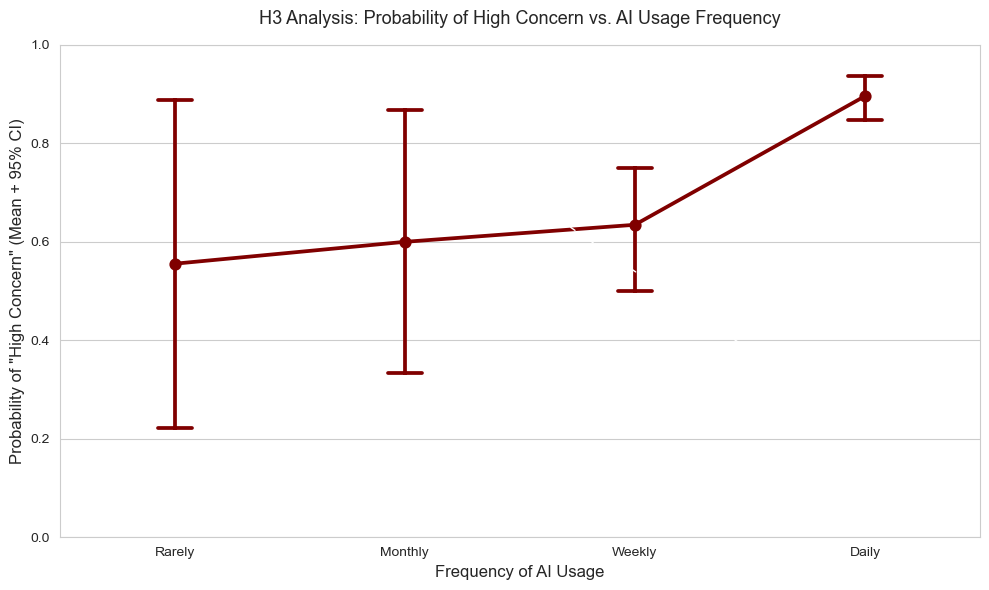

In [70]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Prepare your data
# Assuming your dataframe is named 'df'
# Map your one-hot encoded columns back into a single 'Frequency' column for the X-axis
def map_usage(row):
    if row['AI_Usage_Daily'] == 1: return 'Daily'
    if row['AI_Usage_Weekly- A few times'] == 1: return 'Weekly'
    if row['AI_Usage_Monthly- A few times'] == 1: return 'Monthly'
    return 'Rarely'

df['Usage_Frequency'] = df.apply(map_usage, axis=1)

# 2. Set the professional style
sns.set_style("whitegrid")
plt.figure(figsize=(10, 6))

# 3. Create the Point Plot
# This calculates the mean and 95% confidence interval automatically
usage_order = ['Rarely', 'Monthly', 'Weekly', 'Daily']
ax = sns.pointplot(x='Usage_Frequency', 
                   y='AI_Concern_Yes', 
                   data=df, 
                   order=usage_order,
                   color='maroon', 
                   capsize=.15, 
                   markers='o', 
                   linestyles='-')

# 4. Add the annotation for "Predicted Negative Association"
plt.annotate('' , xy=(3, 0.22), # Pointing to Daily/Low Concern
             xytext=(1.5, 0.7), # Text location
             arrowprops=dict(facecolor='black', arrowstyle='->', linestyle='--'),
             fontsize=11, 
             fontweight='bold')

# 5. Final Formatting
plt.title('H3 Analysis: Probability of High Concern vs. AI Usage Frequency', fontsize=13, pad=15)
plt.xlabel('Frequency of AI Usage', fontsize=12)
plt.ylabel('Probability of "High Concern" (Mean + 95% CI)', fontsize=12)
plt.ylim(0, 1.0) # Scale from 0 to 1 for probability

plt.tight_layout()
plt.show()

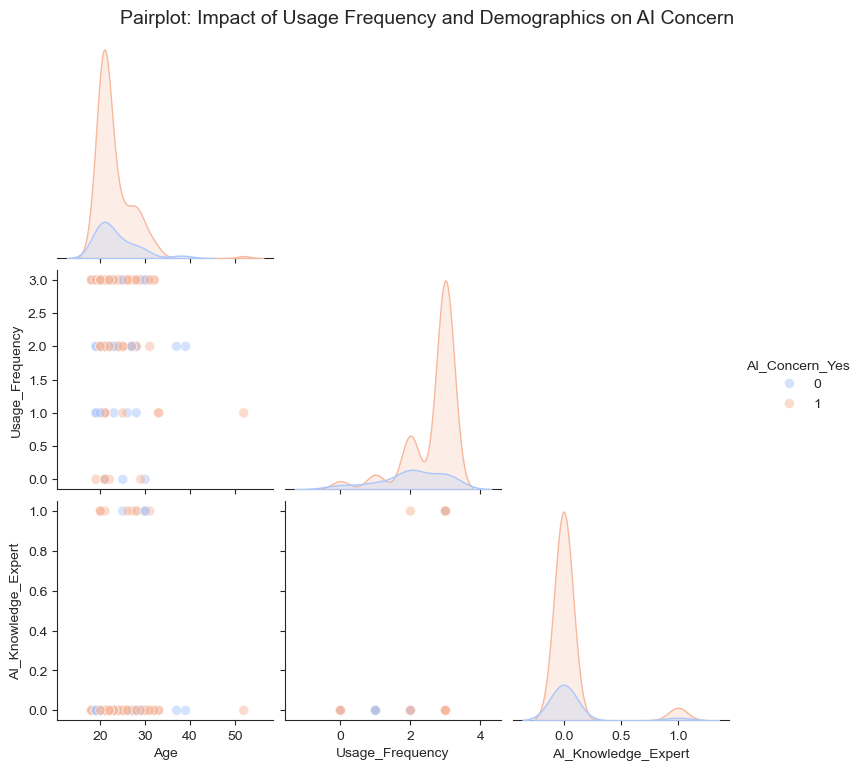

In [75]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Create a numeric index for usage if you haven't yet
# (0=Rarely, 1=Monthly, 2=Weekly, 3=Daily)
def get_usage_index(row):
    if row['AI_Usage_Daily'] == 1: return 3
    if row['AI_Usage_Weekly- A few times'] == 1: return 2
    if row['AI_Usage_Monthly- A few times'] == 1: return 1
    return 0 

df['Usage_Frequency'] = df.apply(get_usage_index, axis=1)

# 2. Select relevant variables
# We include factors that might influence concern to see the full correlation
cols = ['Age', 'Usage_Frequency', 'AI_Knowledge_Expert', 'AI_Concern_Yes']
pair_df = df[cols]

# 3. Generate the Pairplot
# corner=True removes the duplicate upper triangle of the matrix for a cleaner look
sns.set_style("ticks")
g = sns.pairplot(pair_df, 
                 hue='AI_Concern_Yes', 
                 palette='coolwarm', 
                 corner=True, 
                 diag_kind='kde',
                 plot_kws={'alpha': 0.5, 's': 50})

g.fig.suptitle('Pairplot: Impact of Usage Frequency and Demographics on AI Concern', y=1.02, fontsize=14)

plt.savefig('h3_pairplot_analysis.png')
plt.show()